# Day 08. Exercise 05
# Clustering

## 0. Imports

In [620]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [621]:
data = pd.read_csv('../data/regression.csv')

data = data.drop('pageviews', axis=1)

data.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


In [622]:
X = data[['num_commits', 'AVG(diff)']].values
y = data['uid']

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [623]:
kmeans = KMeans(random_state=21, n_clusters=3)
kmeans = kmeans.fit(X)

labels = kmeans.labels_
score = silhouette_score(X, labels)

print(f'Коэффициент силуета: {score}')

Коэффициент силуета: 0.4390170957153295


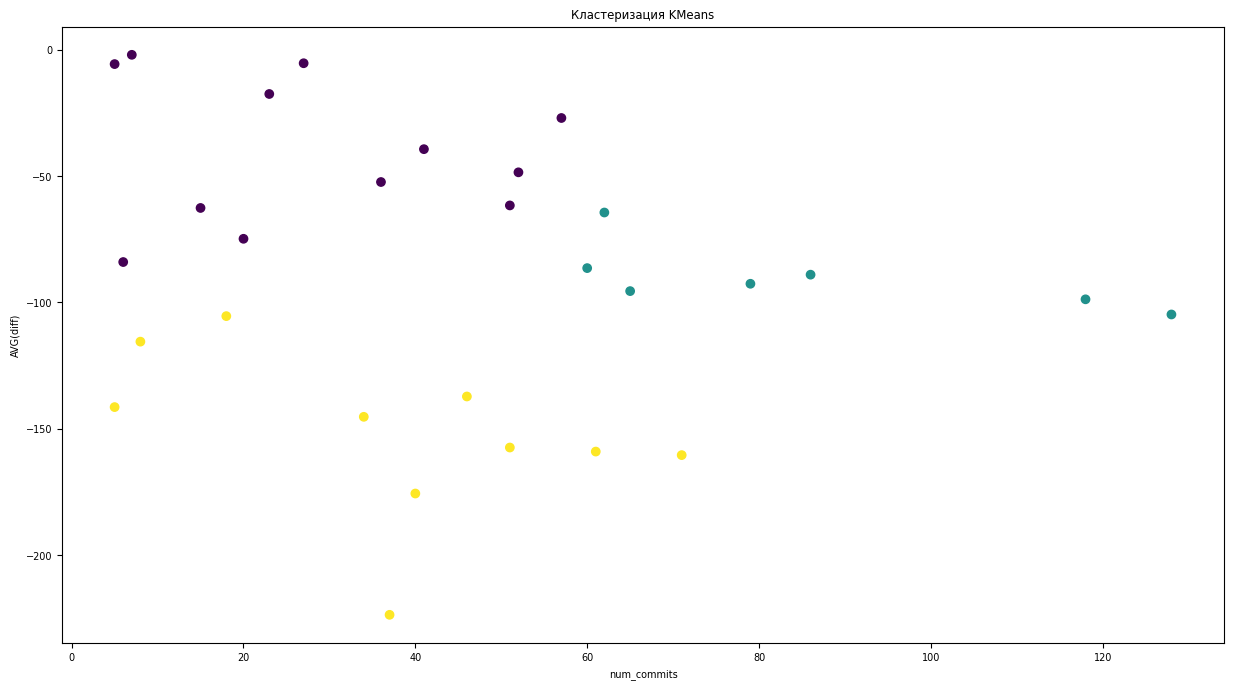

In [624]:
plt.figure(figsize=(15, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('Кластеризация KMeans')
plt.show()

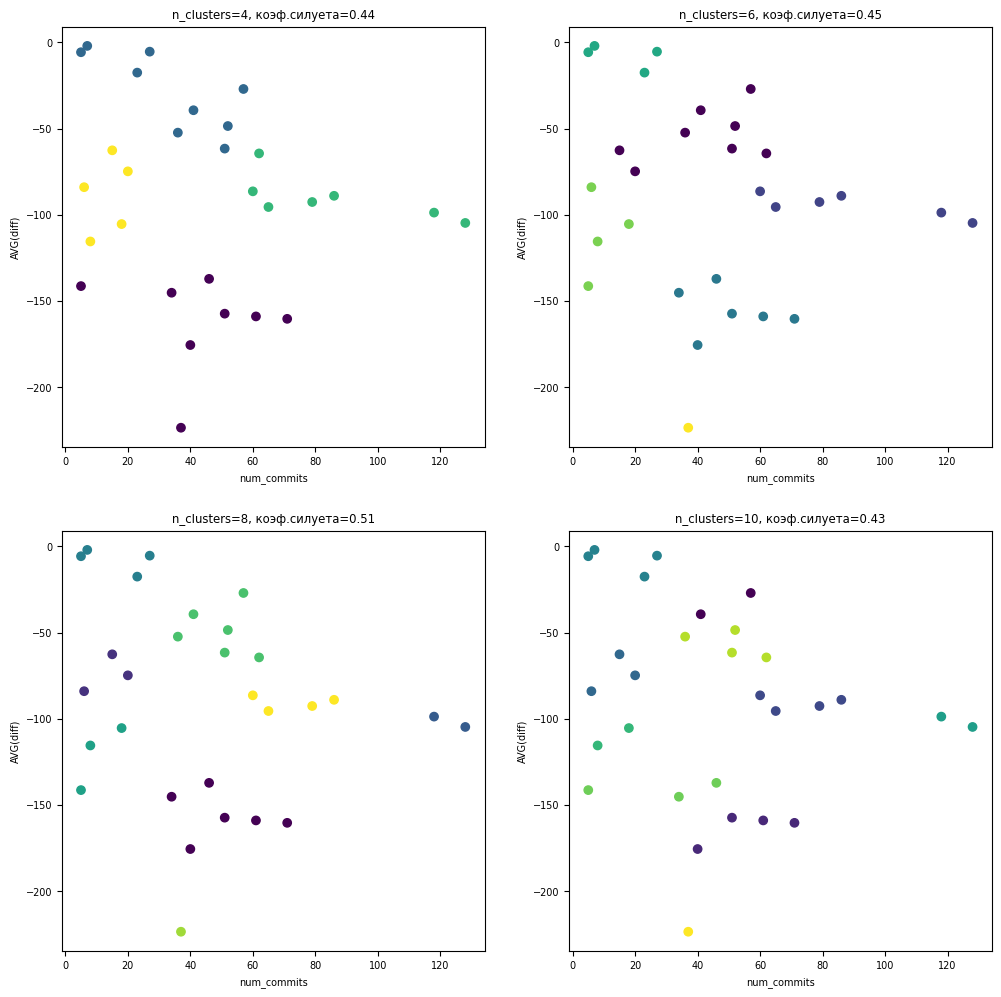

In [625]:
plot_num = 1
plt.figure(figsize=(12, 12))

for clast in range(4, 11, 2):
    kmeans = KMeans(random_state=21, n_clusters=clast)
    kmeans = kmeans.fit(X)

    labels = kmeans.labels_
    score = silhouette_score(X, labels)

    plt.subplot(2, 2, plot_num)
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.title(f'n_clusters={clast}, коэф.силуета={score:.2f}')
    plot_num += 1


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [626]:
dbs = DBSCAN(eps=20, min_samples=2).fit(X)

labels = dbs.labels_
score = silhouette_score(X, labels)

print(f'Коэффициент силуета: {score}')

Коэффициент силуета: 0.38339641455696616


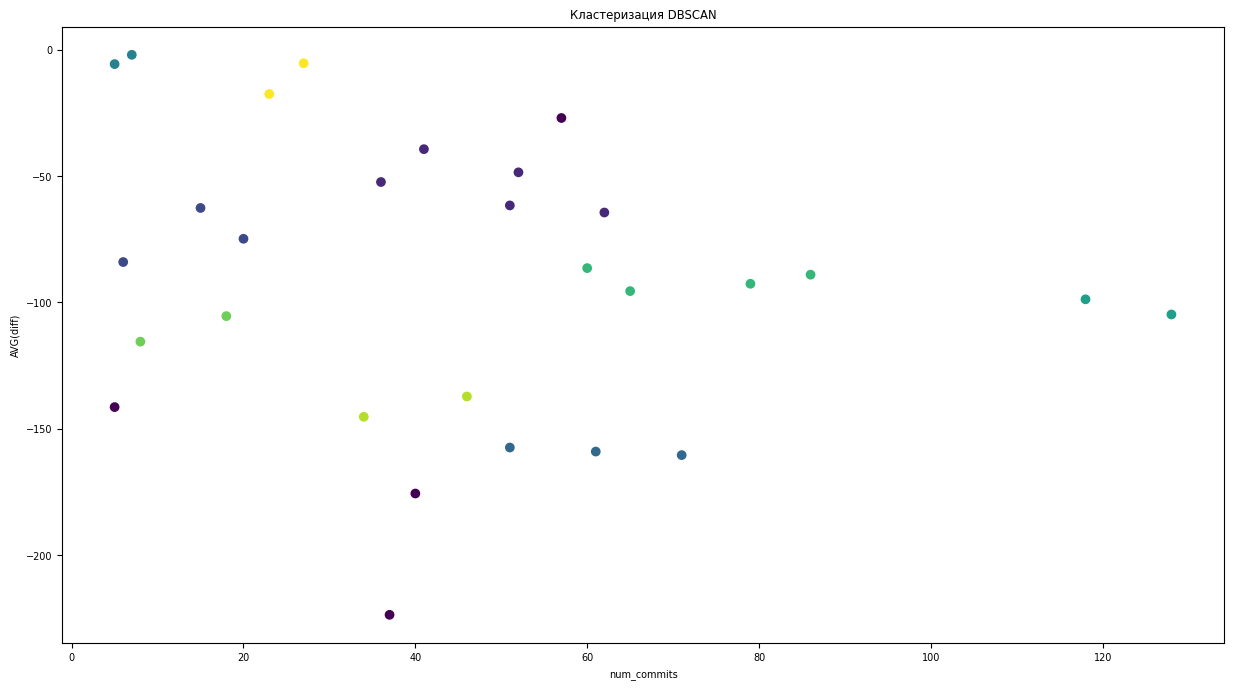

In [627]:
plt.figure(figsize=(15, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('Кластеризация DBSCAN')
plt.show()

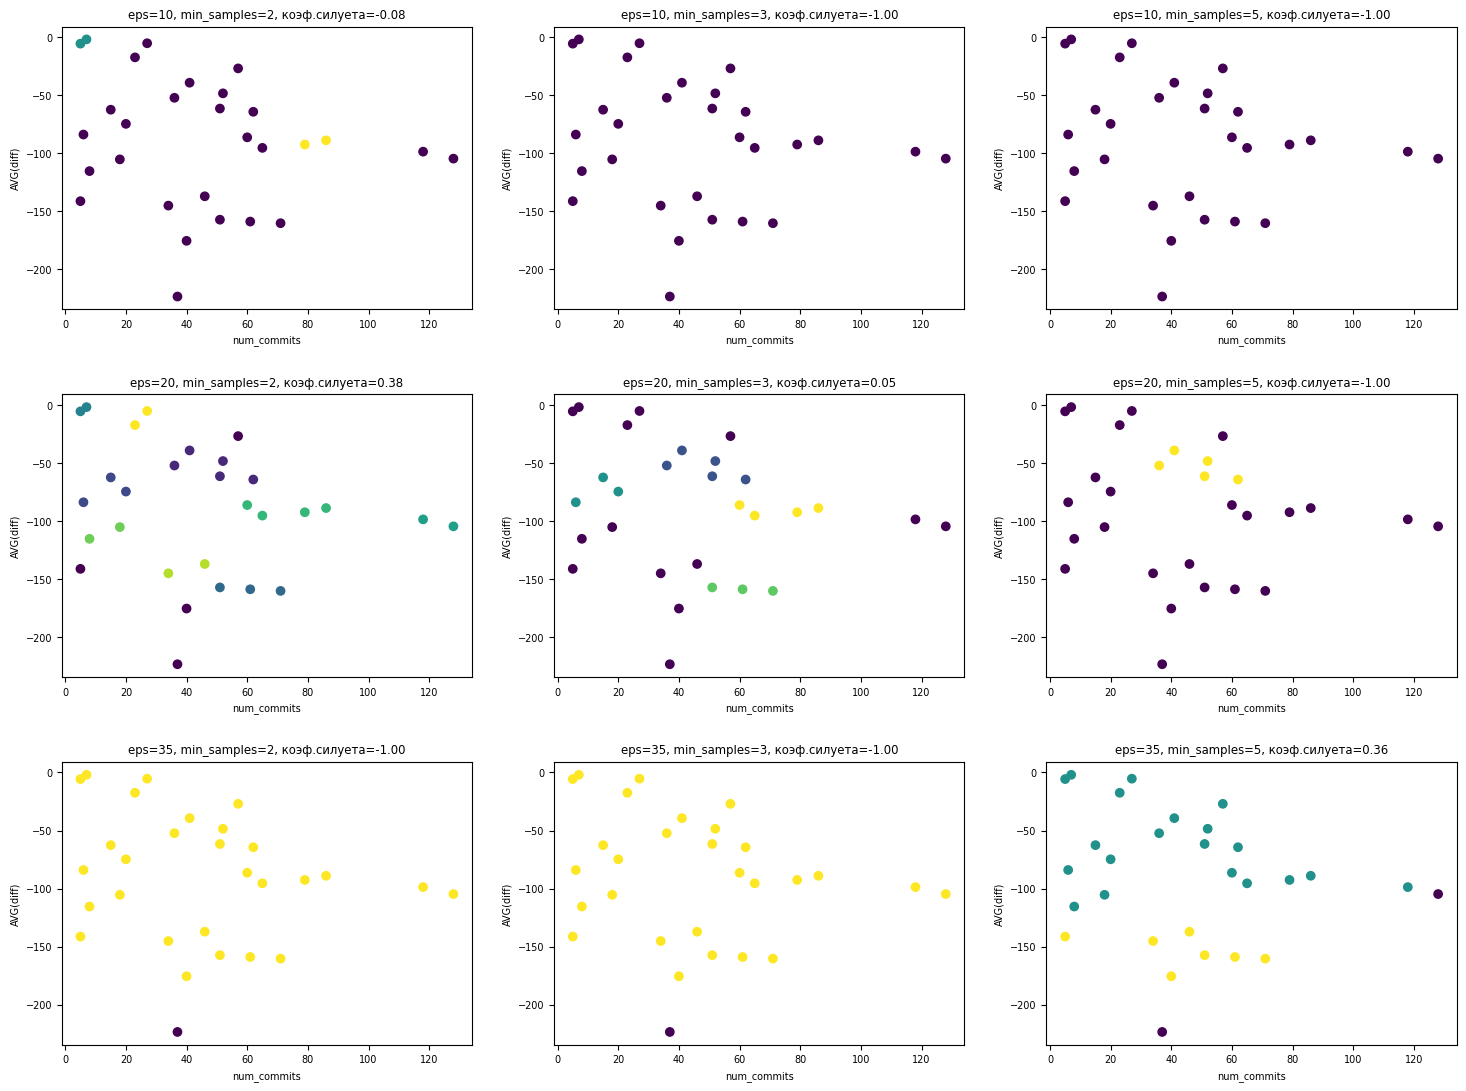

In [628]:
eps_values = [10, 20, 35]
min_samples_values = [2, 3, 5]

plot_num = 1

plt.figure(figsize=(18, 18))
plt.rc('font', size=7)
plt.subplots_adjust(hspace=0.3)

for eps in eps_values:
    for sample in min_samples_values:
        dbs = DBSCAN(eps=eps, min_samples=sample)
        labels = dbs.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1
        
        plt.subplot(4, 3, plot_num)
        plt.xlabel('num_commits')
        plt.ylabel('AVG(diff)')
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
        plt.title(f'eps={eps}, min_samples={sample}, коэф.силуета={score:.2f}')
        plot_num += 1


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [629]:
ac = AgglomerativeClustering(n_clusters=5)
labels = ac.fit_predict(X)
score = silhouette_score(X, labels)

print(f'Коэффициент силуета: {score}')

Коэффициент силуета: 0.46383015199381467


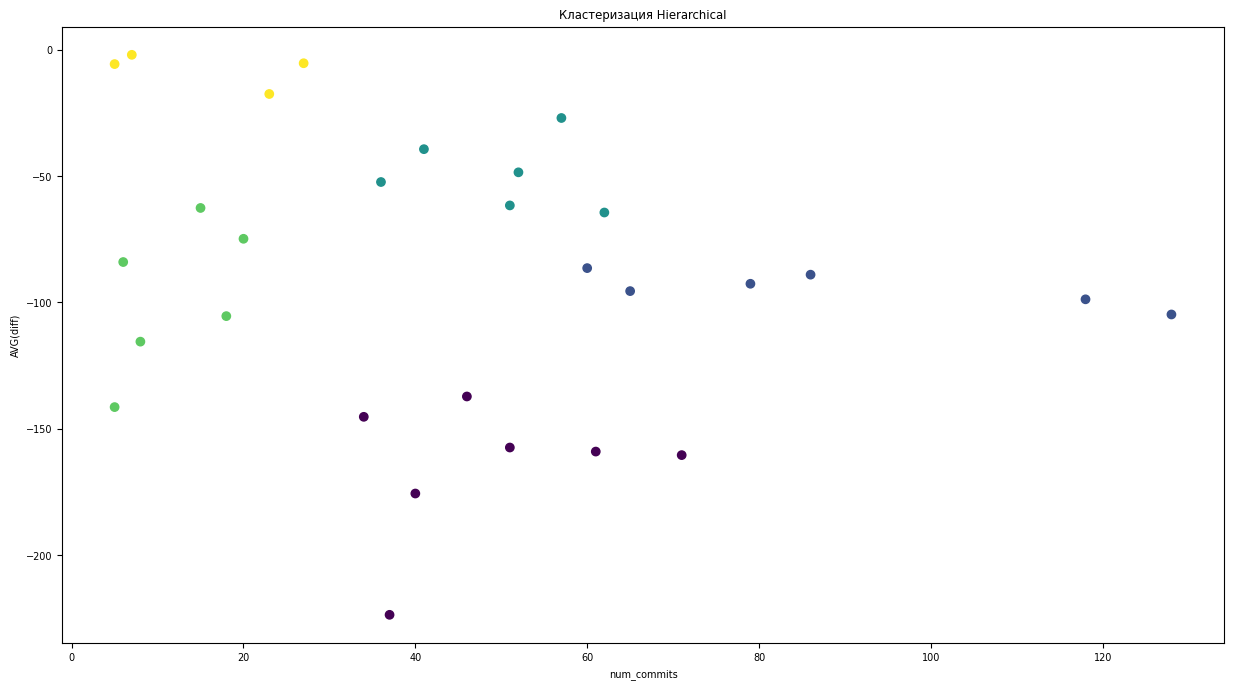

In [630]:
plt.figure(figsize=(15, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('Кластеризация Hierarchical')
plt.show()

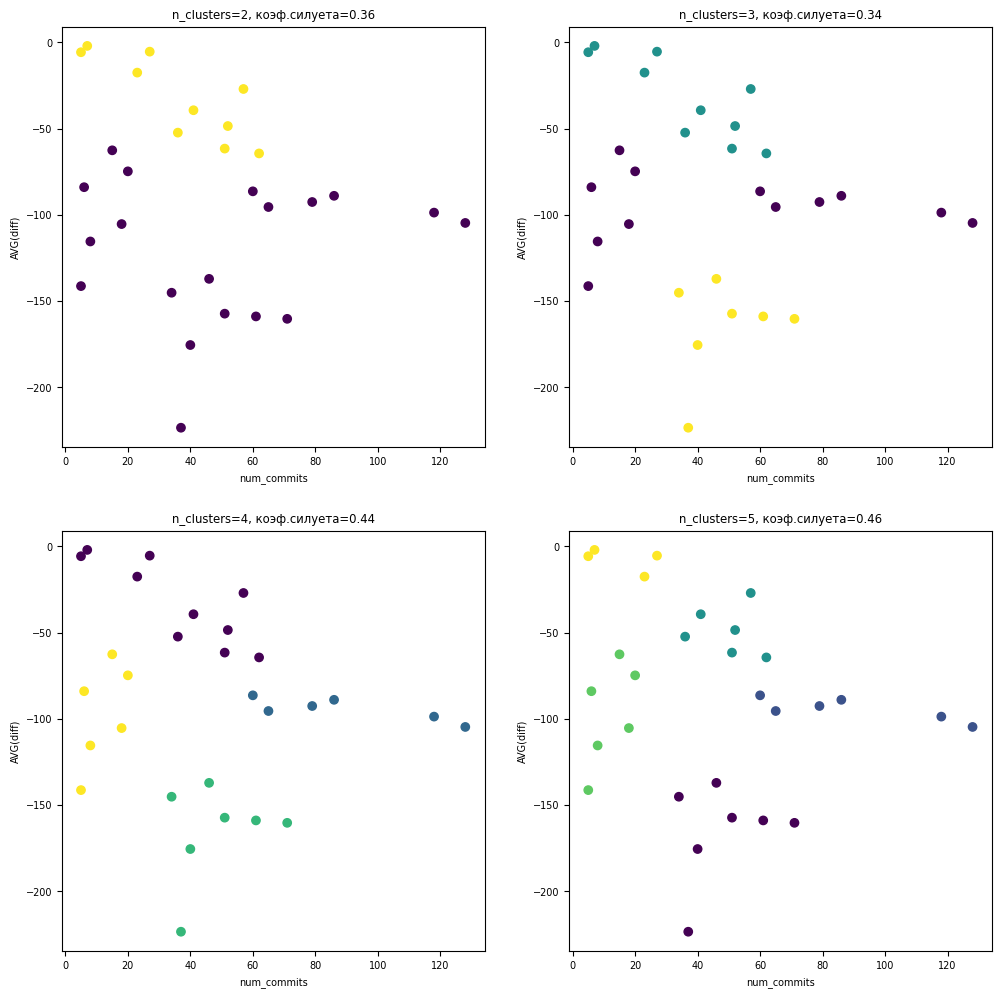

In [631]:
plot_num = 1
plt.figure(figsize=(12, 12))

for clast in range(2, 6):
    
    ac = AgglomerativeClustering(n_clusters=clast)
    labels = ac.fit_predict(X)
    score = silhouette_score(X, labels)

    plt.subplot(2, 2, plot_num)
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.title(f'n_clusters={clast}, коэф.силуета={score:.2f}')
    plot_num += 1

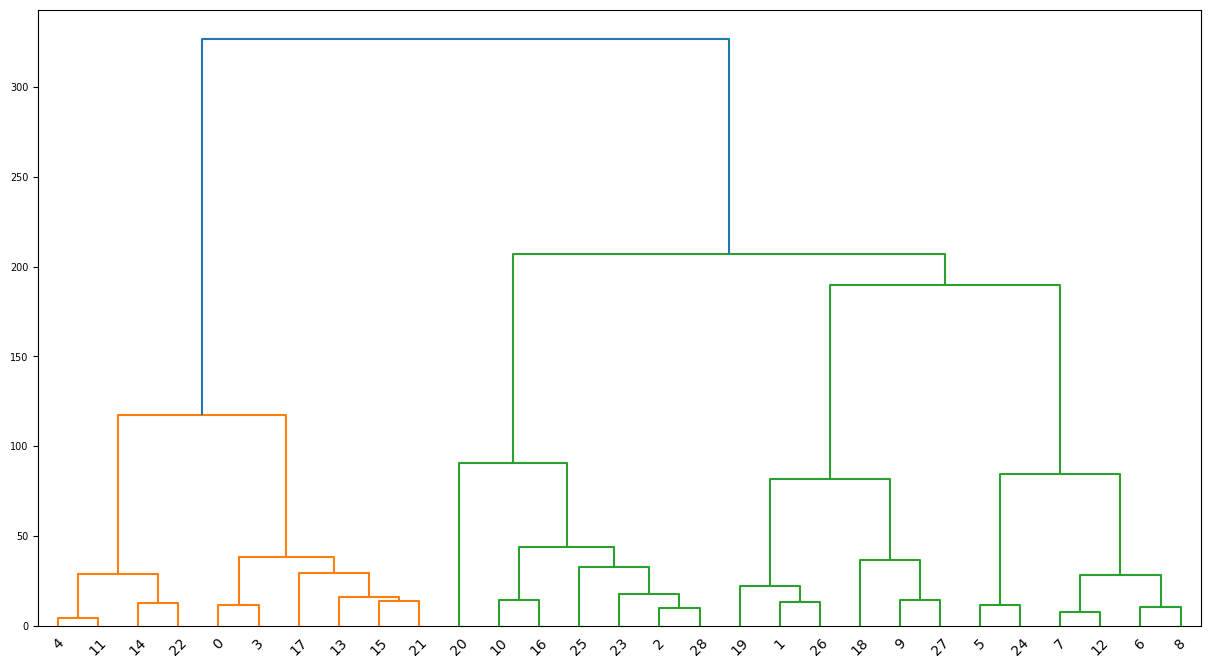

In [632]:
plt.figure(figsize=(15, 8))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [ ]:
def optimize_clustering_simple(model_class, params, param_name, param_range, data):
    scores = []
    best_score = -1
    best_value = None
    best_labels = None
    best_params = ""
    
    for value in param_range:
        current_params = params.copy()
        current_params[param_name] = value
        model = model_class(**current_params)
        labels = model.fit_predict(data)
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(data, labels)
        else:
            score = -1
            
        scores.append(score)
        
        if score > best_score:
            best_score = score
            best_value = value
            best_labels = labels
            best_params = ', '.join([f"{k}:{v}" for k, v in params.items()])
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(param_range, scores)
    plt.xlabel(param_name)
    plt.ylabel('Коэффициент силуета')
    
    plt.subplot(1, 2, 2)
    plt.scatter(data[:, 0], data[:, 1], c=best_labels)
    plt.title(f'Лучший {best_params} {param_name}: {best_value}')
    
    plt.show()
    
    return best_value, best_score


KMeans


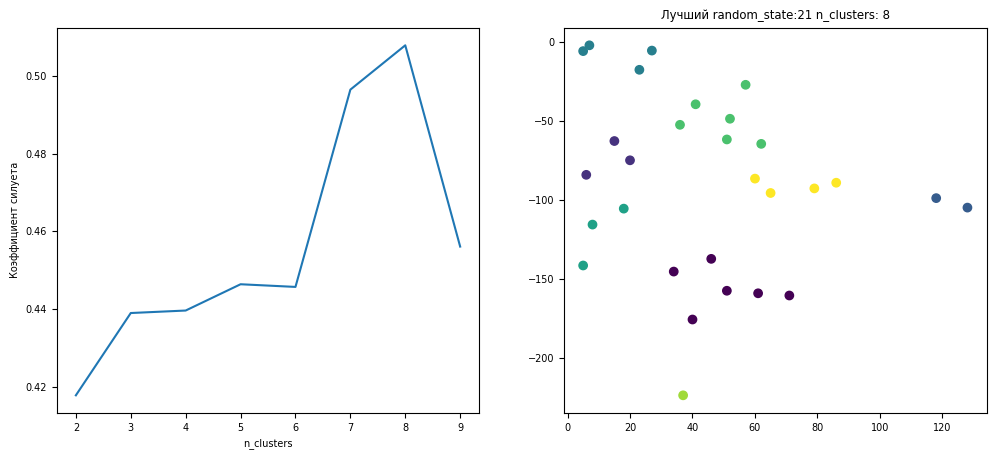


AgglomerativeClustering


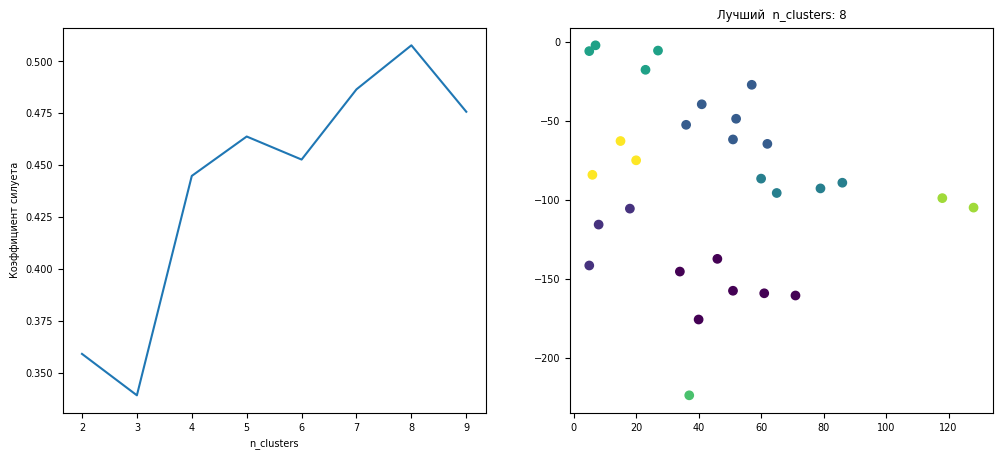


DBSCAN


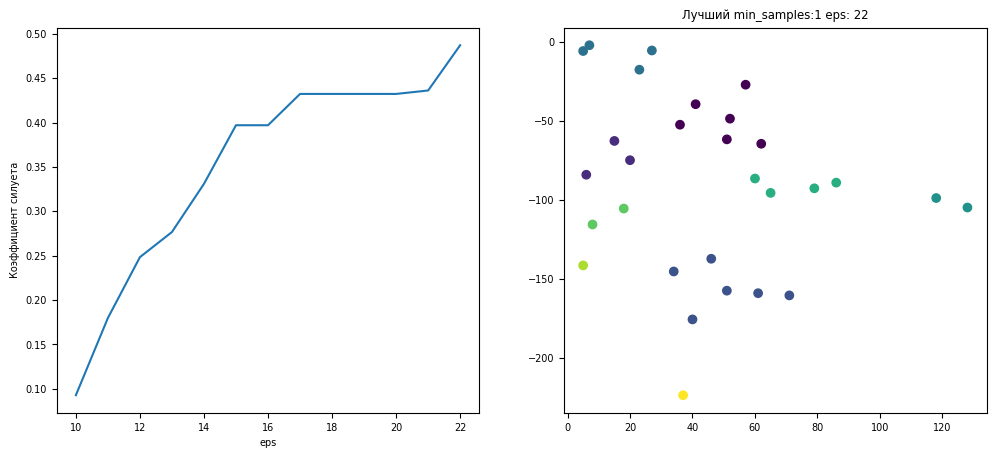

In [634]:
models_configs = [
    (KMeans, {'random_state': 21}, 'n_clusters', range(2, 10)),
    (AgglomerativeClustering, {}, 'n_clusters', range(2, 10)),
    (DBSCAN, {'min_samples': 1}, 'eps', range(10, 23))
]

for model_class, params, param_name, param_range in models_configs:
    print(f"\n{model_class.__name__}")
    optimize_clustering_simple(model_class, params, param_name, param_range, X)